# 🎬 Netflix Data Analysis & Machine Learning Project

**Dataset:** `netflix_titles.csv`
**Objective:** Explore, clean, and build ML models to classify Netflix titles as *Movie* or *TV Show*.

---
| Tool | Purpose |
|---|---|
| Pandas | Data Loading & Cleaning |
| NumPy | Numerical Operations |
| Scikit-learn | Preprocessing & ML |
| Matplotlib / Seaborn | Visualization |
| Plotly | Interactive Dashboard (Bonus) |
| joblib | Model Persistence (Bonus) |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import joblib

sns.set_theme(style='darkgrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
# 📋 Task 1 — Data Loading & Exploration

In [2]:
# 1.1 Load the dataset
df = pd.read_csv('netflix_titles.csv')
print(f'Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns')

Dataset loaded: 8807 rows × 12 columns


In [3]:
# 1.2 First 10 rows
df.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...


In [4]:
# 1.3 Last 10 rows
df.tail(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8797,s8798,TV Show,Zak Storm,NaN,"Michael Johnston, Jessica Gee-George, Christin...","United States, France, South Korea, Indonesia","September 13, 2018",2016,TV-Y7,3 Seasons,Kids' TV,Teen surfer Zak Storm is mysteriously transpor...
8798,s8799,Movie,Zed Plus,Chandra Prakash Dwivedi,"Adil Hussain, Mona Singh, K.K. Raina, Sanjay M...",India,"December 31, 2019",2014,TV-MA,131 min,"Comedies, Dramas, International Movies",A philandering small-town mechanic's political...
8799,s8800,Movie,Zenda,Avadhoot Gupte,"Santosh Juvekar, Siddharth Chandekar, Sachit P...",India,"February 15, 2018",2009,TV-14,120 min,"Dramas, International Movies",A change in the leadership of a political part...
8800,s8801,TV Show,Zindagi Gulzar Hai,NaN,"Sanam Saeed, Fawad Khan, Ayesha Omer, Mehreen ...",Pakistan,"December 15, 2016",2012,TV-PG,1 Season,"International TV Shows, Romantic TV Shows, TV ...","Strong-willed, middle-class Kashaf and carefre..."
8801,s8802,Movie,Zinzana,Majid Al Ansari,"Ali Suliman, Saleh Bakri, Yasa, Ali Al-Jabri, ...","United Arab Emirates, Jordan","March 9, 2016",2015,TV-MA,96 min,"Dramas, International Movies, Thrillers",Recovering alcoholic Talal wakes up inside a s...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [5]:
# 1.4 Shape
print(f'Rows   : {df.shape[0]}')
print(f'Columns: {df.shape[1]}')

Rows   : 8807
Columns: 12


In [6]:
# 1.5 Dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [7]:
# 1.6 Summary statistics
df.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


In [8]:
# 1.7 Data types
print('=== Data Types ===')
print(df.dtypes)

=== Data Types ===
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


In [9]:
# 1.8 Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
print('=== Missing Values ===')
print(missing_df)

=== Missing Values ===
            Missing Count  Missing %
director             2634      29.91
country               831       9.44
cast                  825       9.37
date_added             10       0.11
rating                  4       0.05
duration                3       0.03


In [10]:
# 1.9 Numeric vs Categorical columns
numeric_cols     = df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f'Numeric columns     ({len(numeric_cols)}): {numeric_cols}')
print(f'Categorical columns ({len(categorical_cols)}): {categorical_cols}')

Numeric columns     (1): ['release_year']
Categorical columns (11): ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'rating', 'duration', 'listed_in', 'description']


In [11]:
# 1.10 Movies vs TV Shows count & percentage
type_counts  = df['type'].value_counts()
type_pct     = df['type'].value_counts(normalize=True).mul(100).round(2)
type_summary = pd.DataFrame({'Count': type_counts, 'Percentage (%)': type_pct})
print('=== Content Type Distribution ===')
print(type_summary)

# 1.11 Unique stats
print('\n=== Key Dataset Statistics ===')
print('Total unique countries :', df['country'].dropna().str.split(',').explode().str.strip().nunique())
print('Total unique directors :', df['director'].dropna().str.split(',').explode().str.strip().nunique())
print('Total unique genres    :', df['listed_in'].dropna().str.split(',').explode().str.strip().nunique())
print('Earliest release year  :', df['release_year'].min())
print('Latest release year    :', df['release_year'].max())

=== Content Type Distribution ===
         Count  Percentage (%)
type                          
Movie     6131           69.62
TV Show   2676           30.38

=== Key Dataset Statistics ===
Total unique countries : 123
Total unique directors : 4993
Total unique genres    : 42
Earliest release year  : 1925
Latest release year    : 2021


### 🔍 Observation

- **Movies vs TV Shows:** Netflix is **dominated by Movies**, accounting for roughly 69–70% of all titles. TV Shows make up the remaining ~30%.
- **Dataset Balance:** The dataset is **imbalanced** — Movies outnumber TV Shows approximately 2:1. This should be accounted for during ML model training.

---
# 🧹 Task 2 — Data Cleaning & Preprocessing

In [12]:
# 2.1 Work on a copy
df_clean = df.copy()

# 2.2 Handle Missing Values
df_clean['director'].fillna('Unknown', inplace=True)
df_clean['cast'].fillna('Unknown', inplace=True)
df_clean['country'].fillna('Unknown', inplace=True)
df_clean['date_added'].fillna('January 1, 2000', inplace=True)
df_clean['rating'].fillna(df_clean['rating'].mode()[0], inplace=True)
df_clean['duration'].fillna('0 min', inplace=True)

print(f'Missing values after cleaning: {df_clean.isnull().sum().sum()}')

Missing values after cleaning: 0


In [13]:
# 2.3 Remove Duplicate Records
before = len(df_clean)
df_clean.drop_duplicates(inplace=True)
after = len(df_clean)
print(f'Duplicates removed: {before - after}  (Rows remaining: {after})')

Duplicates removed: 0  (Rows remaining: 8807)


In [14]:
# 2.4 Convert date_added to datetime; extract Year & Month Added
df_clean['date_added'] = pd.to_datetime(df_clean['date_added'].str.strip(), format='mixed', errors='coerce')
df_clean['year_added']  = df_clean['date_added'].dt.year
df_clean['month_added'] = df_clean['date_added'].dt.month

print('date_added dtype:', df_clean['date_added'].dtype)
print(df_clean[['date_added', 'year_added', 'month_added']].head())

date_added dtype: datetime64[ns]
  date_added  year_added  month_added
0 2021-09-25        2021            9
1 2021-09-24        2021            9
2 2021-09-24        2021            9
3 2021-09-24        2021            9
4 2021-09-24        2021            9


In [15]:
# 2.5 Feature Engineering
# Movie Duration in minutes
df_clean['duration_minutes'] = df_clean.apply(
    lambda row: int(row['duration'].replace(' min', '').strip())
    if row['type'] == 'Movie' and 'min' in str(row['duration'])
    else 0, axis=1
)

# TV Show Seasons
df_clean['seasons'] = df_clean.apply(
    lambda row: int(row['duration'].replace(' Seasons', '').replace(' Season', '').strip())
    if row['type'] == 'TV Show' and 'Season' in str(row['duration'])
    else 0, axis=1
)

print('Feature Engineering complete:')
print(df_clean[['type', 'duration', 'duration_minutes', 'seasons']].head(10))

Feature Engineering complete:
      type   duration  duration_minutes  seasons
0    Movie     90 min                90        0
1  TV Show  2 Seasons                 0        2
2  TV Show   1 Season                 0        1
3  TV Show   1 Season                 0        1
4  TV Show  2 Seasons                 0        2
5  TV Show   1 Season                 0        1
6    Movie     91 min                91        0
7    Movie    125 min               125        0
8  TV Show  9 Seasons                 0        9
9    Movie    104 min               104        0


In [16]:
# 2.6 One-Hot Encode Categorical Columns
# Use primary (first) country and genre
df_clean['primary_country'] = df_clean['country'].str.split(',').str[0].str.strip()
df_clean['primary_genre']   = df_clean['listed_in'].str.split(',').str[0].str.strip()

# Keep top 15 for OHE to avoid explosion
top_countries = df_clean['primary_country'].value_counts().nlargest(15).index
top_genres    = df_clean['primary_genre'].value_counts().nlargest(15).index

df_clean['primary_country'] = df_clean['primary_country'].where(
    df_clean['primary_country'].isin(top_countries), other='Other')
df_clean['primary_genre'] = df_clean['primary_genre'].where(
    df_clean['primary_genre'].isin(top_genres), other='Other')

df_encoded = pd.get_dummies(df_clean, columns=['rating', 'primary_country', 'primary_genre'], drop_first=False)

# Encode target: 1 = Movie, 0 = TV Show
df_encoded['type_encoded'] = (df_encoded['type'] == 'Movie').astype(int)
print(f'Shape after One-Hot Encoding: {df_encoded.shape}')

Shape after One-Hot Encoding: (8807, 65)


In [17]:
# 2.7 Scale Numeric Features with StandardScaler
scaler = StandardScaler()
numeric_features = ['release_year', 'duration_minutes', 'seasons']

df_encoded[['release_year_scaled', 'duration_minutes_scaled', 'seasons_scaled']] = \
    scaler.fit_transform(df_encoded[numeric_features])

print('Scaled features sample:')
df_encoded[['release_year_scaled', 'duration_minutes_scaled', 'seasons_scaled']].describe().round(3)

Scaled features sample:


,release_year_scaled,duration_minutes_scaled,seasons_scaled
count,8807.000,8807.000,8807.000
mean,0.000,-0.000,0.000
std,1.000,1.000,1.000
min,-10.112,-1.345,-0.450
25%,-0.134,-1.345,-0.450
50%,0.320,0.363,-0.450
75%,0.547,0.712,0.389
max,0.773,4.710,13.817


---
# 📊 Task 3 — Exploratory Data Analysis (EDA)

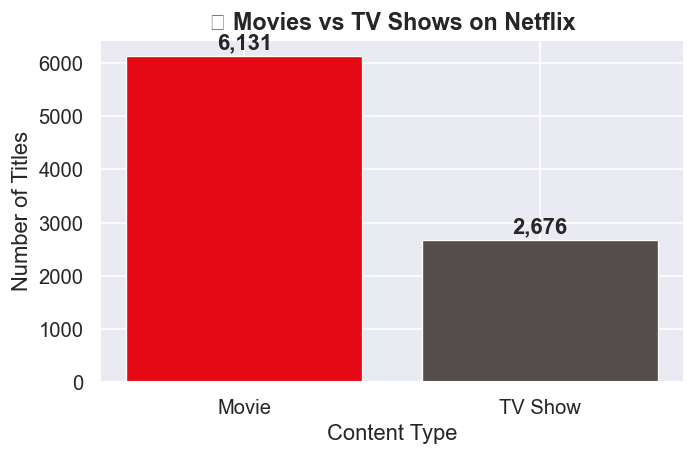

In [18]:
# ── 3.1 Content by Type ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
type_counts = df_clean['type'].value_counts()
colors = ['#E50914', '#564d4d']
bars = ax.bar(type_counts.index, type_counts.values, color=colors, edgecolor='white', linewidth=0.8)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{bar.get_height():,}', ha='center', va='bottom', fontweight='bold')
ax.set_title('🎬 Movies vs TV Shows on Netflix', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Titles')
ax.set_xlabel('Content Type')
plt.tight_layout()
plt.show()

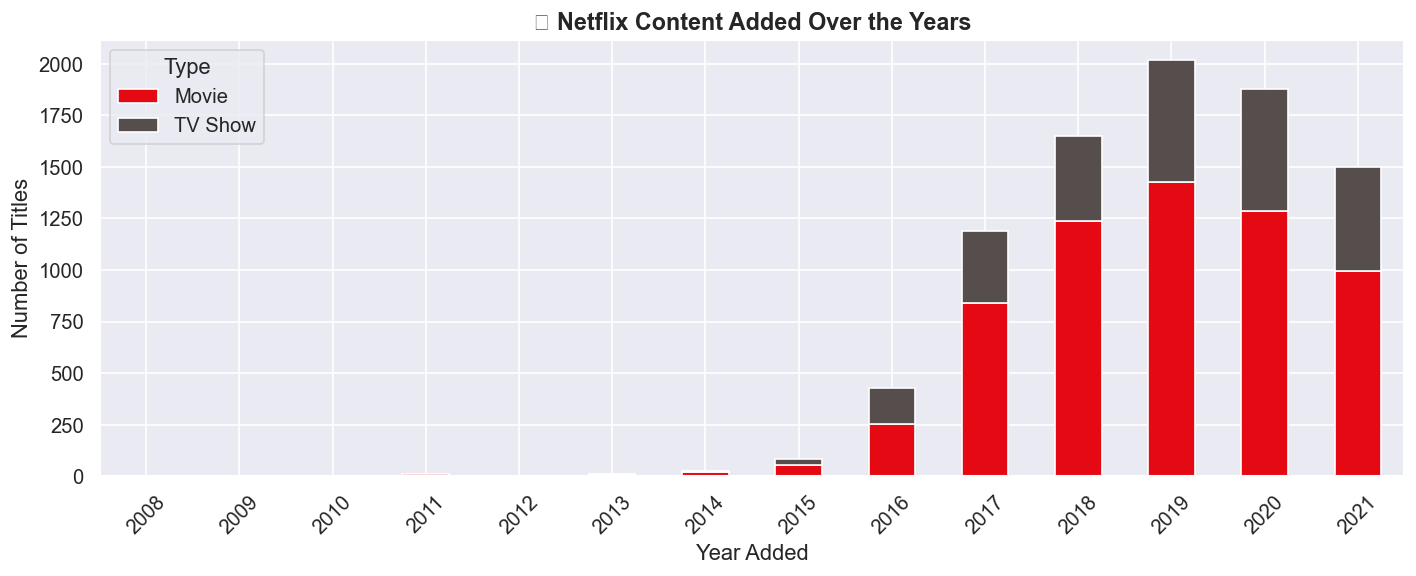

In [19]:
# ── 3.2 Content Added Over Time ──────────────────────────────────────────
added_by_year = df_clean.groupby(['year_added', 'type']).size().unstack(fill_value=0)
added_by_year = added_by_year[added_by_year.index.notna() & (added_by_year.index >= 2008)]

fig, ax = plt.subplots(figsize=(12, 5))
added_by_year.plot(kind='bar', stacked=True, ax=ax, color=['#E50914', '#564d4d'])
ax.set_title('📅 Netflix Content Added Over the Years', fontsize=14, fontweight='bold')
ax.set_xlabel('Year Added')
ax.set_ylabel('Number of Titles')
ax.legend(title='Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

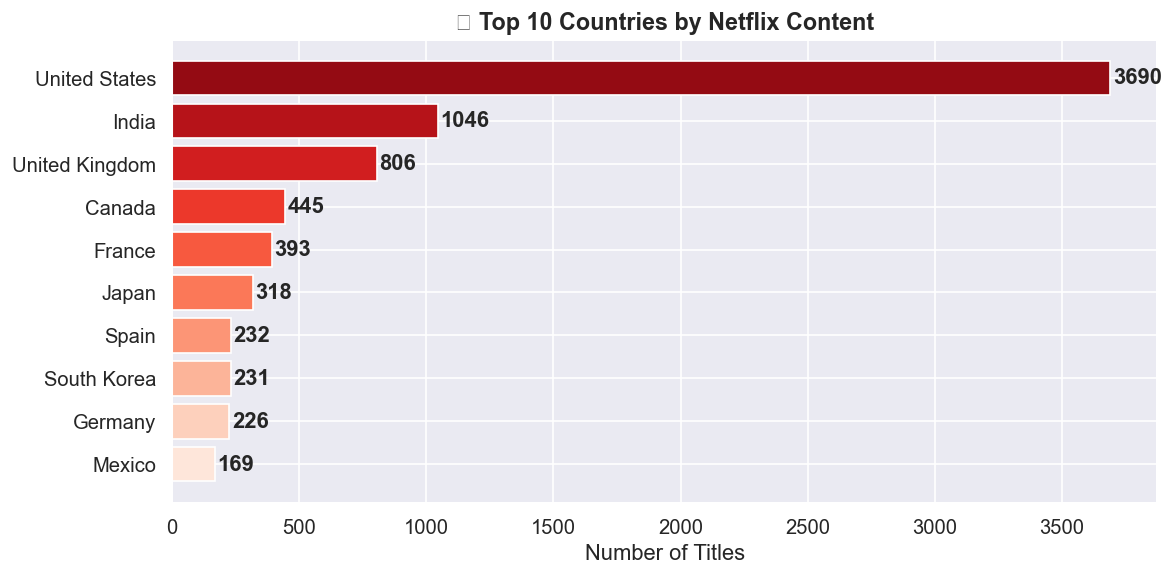

In [20]:
# ── 3.3 Top 10 Countries ─────────────────────────────────────────────────
country_series = df_clean['country'].str.split(',').explode().str.strip()
country_series = country_series[country_series != 'Unknown']
top10_countries = country_series.value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
palette_c = sns.color_palette('Reds_r', 10)
ax.barh(top10_countries.index[::-1], top10_countries.values[::-1], color=palette_c[::-1])
ax.set_title('🌍 Top 10 Countries by Netflix Content', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Titles')
for i, v in enumerate(top10_countries.values[::-1]):
    ax.text(v + 10, i, str(v), va='center', fontweight='bold')
plt.tight_layout()
plt.show()

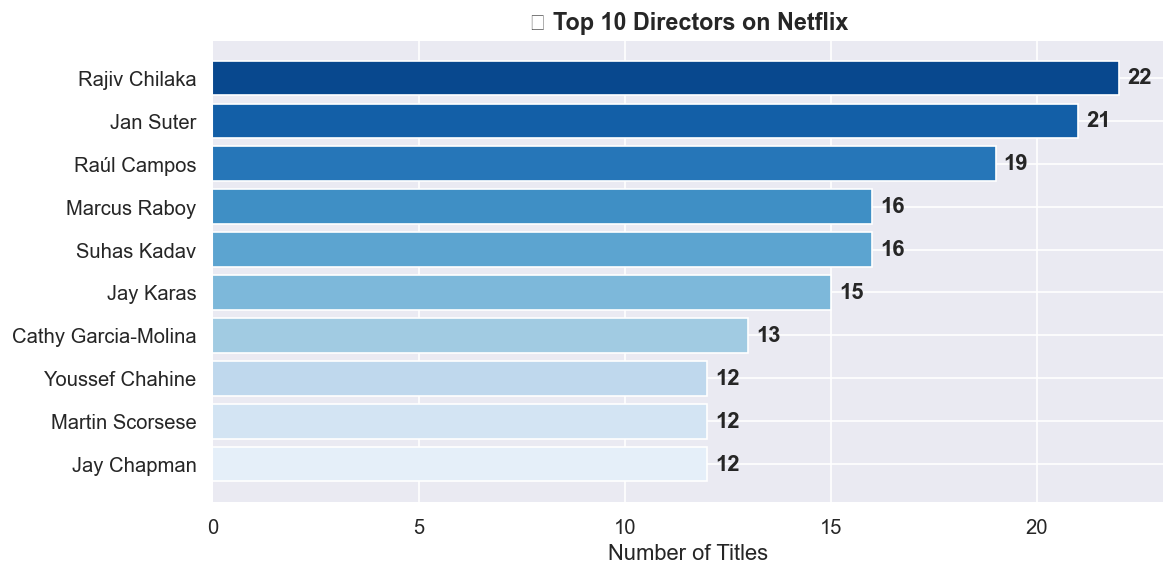

In [21]:
# ── 3.4 Top 10 Directors ─────────────────────────────────────────────────
director_series = df_clean['director']
director_series = director_series[director_series != 'Unknown']
director_series = director_series.str.split(',').explode().str.strip()
top10_directors = director_series.value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
palette_d = sns.color_palette('Blues_r', 10)
ax.barh(top10_directors.index[::-1], top10_directors.values[::-1], color=palette_d[::-1])
ax.set_title('🎥 Top 10 Directors on Netflix', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Titles')
for i, v in enumerate(top10_directors.values[::-1]):
    ax.text(v + 0.2, i, str(v), va='center', fontweight='bold')
plt.tight_layout()
plt.show()

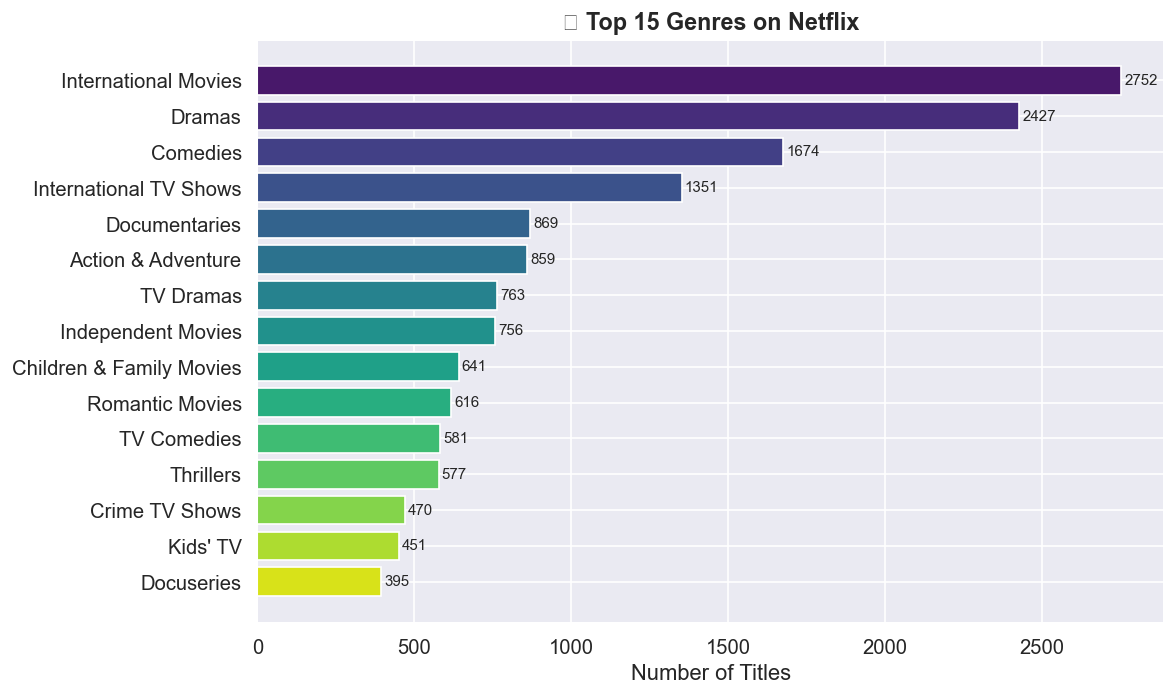

In [22]:
# ── 3.5 Top Genres ───────────────────────────────────────────────────────
genre_series = df_clean['listed_in'].str.split(',').explode().str.strip()
top15_genres = genre_series.value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
palette_g = sns.color_palette('viridis', 15)
ax.barh(top15_genres.index[::-1], top15_genres.values[::-1], color=palette_g[::-1])
ax.set_title('🎭 Top 15 Genres on Netflix', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Titles')
for i, v in enumerate(top15_genres.values[::-1]):
    ax.text(v + 10, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.show()

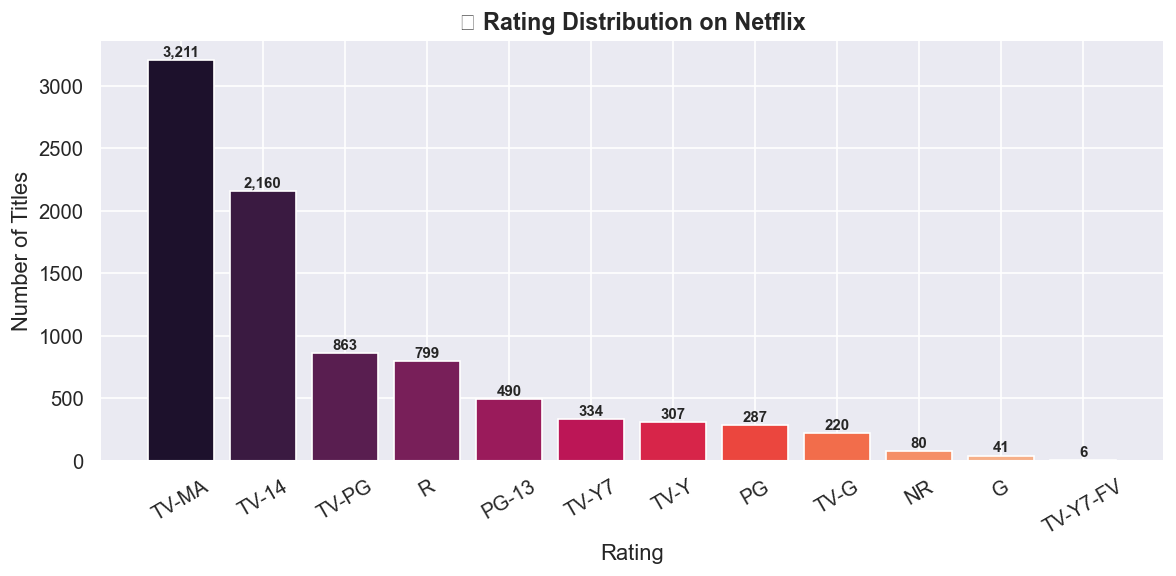

In [23]:
# ── 3.6 Rating Distribution ──────────────────────────────────────────────
rating_counts = df_clean['rating'].value_counts().head(12)

fig, ax = plt.subplots(figsize=(10, 5))
palette_r = sns.color_palette('rocket', len(rating_counts))
bars = ax.bar(rating_counts.index, rating_counts.values, color=palette_r, edgecolor='white')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{bar.get_height():,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title('⭐ Rating Distribution on Netflix', fontsize=14, fontweight='bold')
ax.set_xlabel('Rating')
ax.set_ylabel('Number of Titles')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

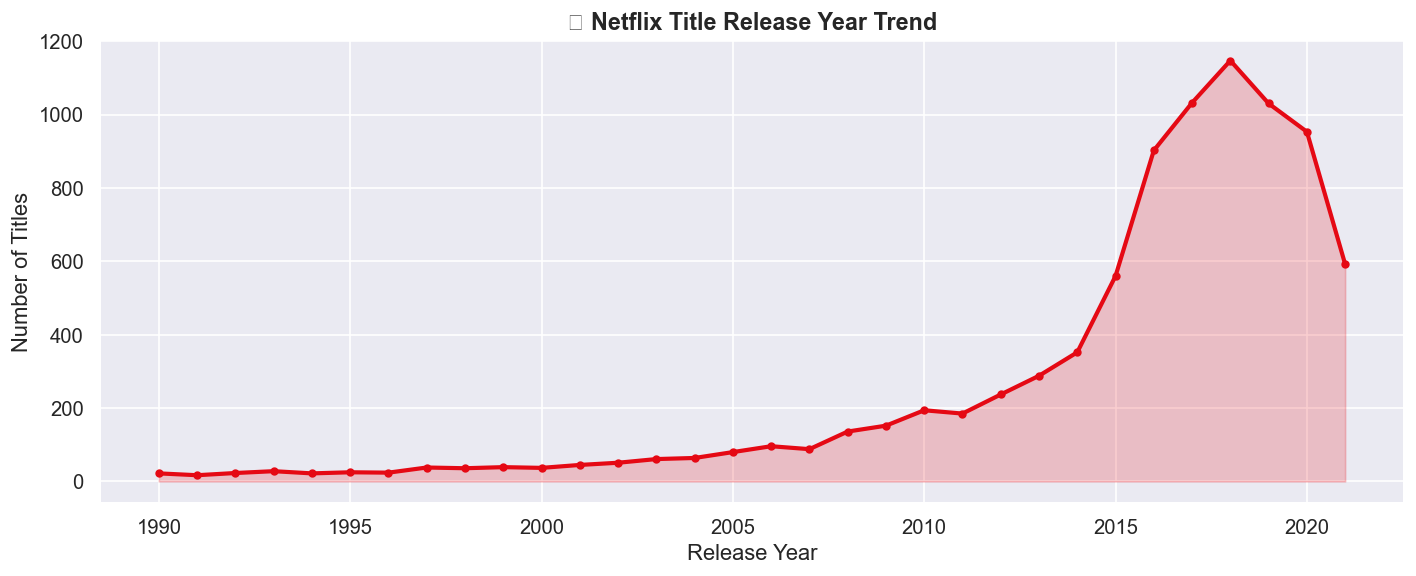

In [24]:
# ── 3.7 Release Year Trend ───────────────────────────────────────────────
release_trend = df_clean['release_year'].value_counts().sort_index()
release_trend = release_trend[release_trend.index >= 1990]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(release_trend.index, release_trend.values, color='#E50914', linewidth=2.5, marker='o', markersize=4)
ax.fill_between(release_trend.index, release_trend.values, alpha=0.2, color='#E50914')
ax.set_title('📈 Netflix Title Release Year Trend', fontsize=14, fontweight='bold')
ax.set_xlabel('Release Year')
ax.set_ylabel('Number of Titles')
plt.tight_layout()
plt.show()

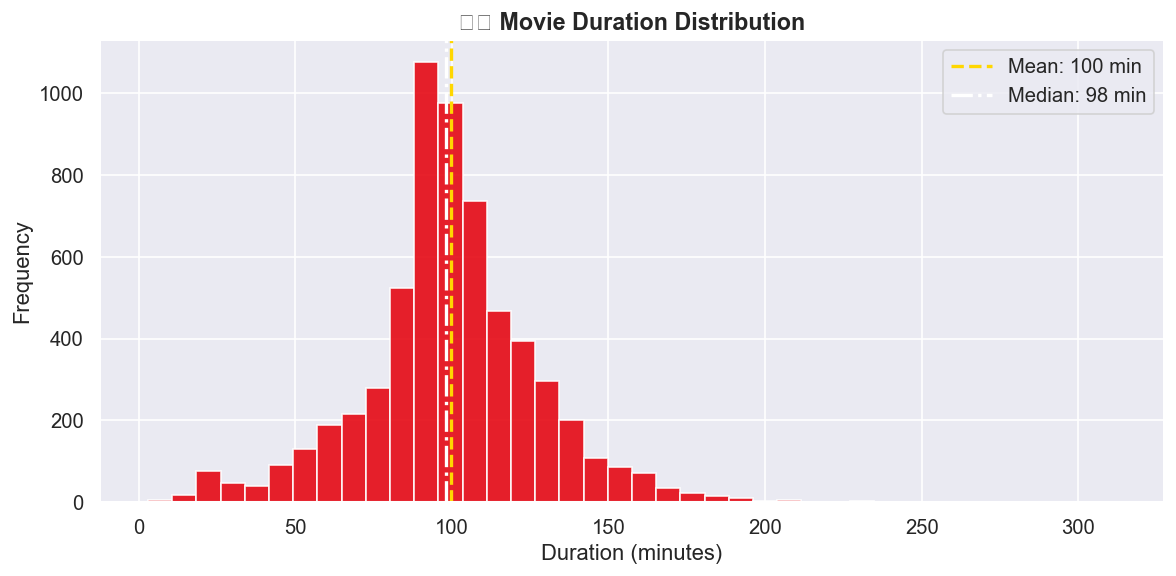

In [25]:
# ── 3.8 Movie Duration Distribution ─────────────────────────────────────
movie_durations = df_clean[df_clean['type'] == 'Movie']['duration_minutes']
movie_durations = movie_durations[movie_durations > 0]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(movie_durations, bins=40, color='#E50914', edgecolor='white', alpha=0.9)
ax.axvline(movie_durations.mean(),   color='gold',  linewidth=2, linestyle='--',
           label=f'Mean: {movie_durations.mean():.0f} min')
ax.axvline(movie_durations.median(), color='white', linewidth=2, linestyle='-.',
           label=f'Median: {movie_durations.median():.0f} min')
ax.set_title('⏱️ Movie Duration Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Duration (minutes)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

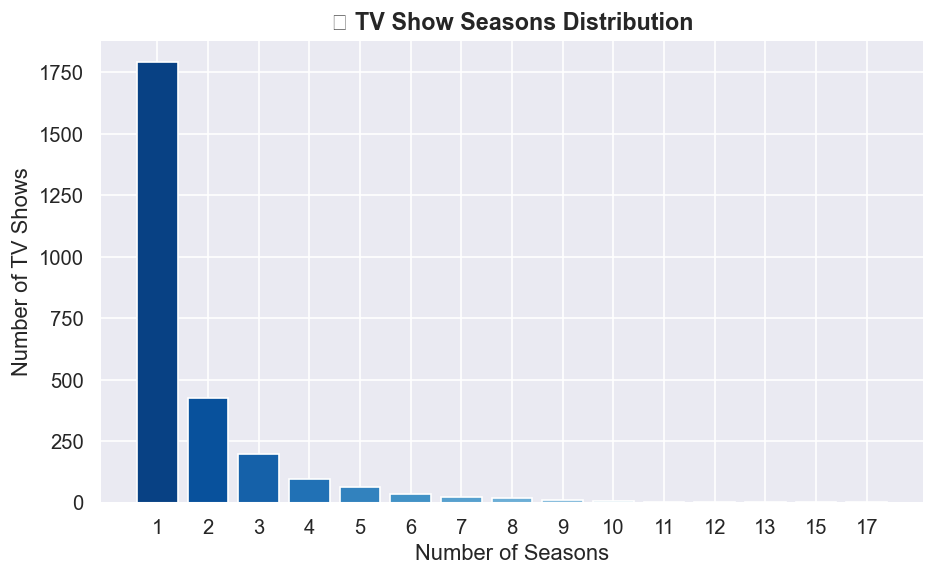

In [26]:
# ── 3.9 TV Seasons Distribution ──────────────────────────────────────────
tv_seasons = df_clean[df_clean['type'] == 'TV Show']['seasons']
tv_seasons = tv_seasons[tv_seasons > 0]
season_counts = tv_seasons.value_counts().sort_index().head(15)

fig, ax = plt.subplots(figsize=(8, 5))
palette_s = sns.color_palette('Blues_r', len(season_counts))
ax.bar(season_counts.index.astype(str), season_counts.values, color=palette_s, edgecolor='white')
ax.set_title('📺 TV Show Seasons Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Seasons')
ax.set_ylabel('Number of TV Shows')
plt.tight_layout()
plt.show()

### 💡 Business Insights from EDA

1. **Netflix is Movie-heavy (~70%):** Films dominate the catalog, suggesting a historical focus on licensing movies before the pivot to originals.
2. **US Content Dominates:** The United States leads by a wide margin; India and the UK follow — indicating an opportunity to grow content from underrepresented regions.
3. **TV-MA is the Most Common Rating:** Netflix primarily targets **adult audiences**, with mature-rated content far outnumbering family or children's programming.
4. **Content Addition Peaked 2016–2019:** Rapid growth aligns with Netflix's global expansion phase; COVID-19 production slowdowns caused a subsequent dip.
5. **Movies Cluster at 90–120 Minutes:** The duration distribution is nearly normal with a slight right skew, matching standard theatrical release lengths.

---
# 🤖 Task 4 — Machine Learning

**Problem:** Predict whether a Netflix title is a **Movie** or **TV Show** (binary classification).

In [27]:
# 4.1 Prepare Feature Matrix
ohe_cols     = [c for c in df_encoded.columns if c.startswith(('rating_', 'primary_country_', 'primary_genre_'))]
feature_cols = ['release_year_scaled', 'duration_minutes_scaled', 'seasons_scaled'] + ohe_cols

X = df_encoded[feature_cols].fillna(0)
y = df_encoded['type_encoded']   # 1 = Movie, 0 = TV Show

print(f'Feature matrix shape: {X.shape}')
print(f'Target distribution:\n{y.value_counts()}')

Feature matrix shape: (8807, 52)
Target distribution:
type_encoded
1    6131
0    2676
Name: count, dtype: int64


In [28]:
# 4.2 Train / Test Split  80 % / 20 %
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

print(f'Training set : {X_train.shape[0]} samples')
print(f'Testing set  : {X_test.shape[0]} samples')

Training set : 7045 samples
Testing set  : 1762 samples


In [29]:
# 4.3 Train all three models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results        = {}
trained_models = {}

for name, model in models.items():
    print(f'Training {name}...', end=' ')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results[name] = {
        'Accuracy' : round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall'   : round(recall_score(y_test, y_pred), 4),
        'F1 Score' : round(f1_score(y_test, y_pred), 4),
        'ROC-AUC'  : round(roc_auc_score(y_test, y_prob), 4)
    }
    trained_models[name] = (model, y_pred, y_prob)
    print('✅ Done')

Training Logistic Regression... ✅ Done
Training Random Forest... ✅ Done
Training Gradient Boosting... ✅ Done


In [30]:
# 4.4 Comparison Table
results_df = pd.DataFrame(results).T.sort_values('F1 Score', ascending=False)
print('=== Model Comparison Table ===')
print(results_df.to_string())

=== Model Comparison Table ===
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression       1.0        1.0     1.0       1.0      1.0
Random Forest             1.0        1.0     1.0       1.0      1.0
Gradient Boosting         1.0        1.0     1.0       1.0      1.0


---
# 📈 Task 5 — Model Evaluation

In [31]:
# 5.1 Detailed evaluation of all models
for name, (model, y_pred, y_prob) in trained_models.items():
    print('=' * 60)
    print(f'  {name.upper()}')
    print('=' * 60)
    print(f'  Accuracy  : {accuracy_score(y_test, y_pred):.4f}')
    print(f'  Precision : {precision_score(y_test, y_pred):.4f}')
    print(f'  Recall    : {recall_score(y_test, y_pred):.4f}')
    print(f'  F1 Score  : {f1_score(y_test, y_pred):.4f}')
    print(f'  ROC-AUC   : {roc_auc_score(y_test, y_prob):.4f}')
    print()
    print('  Classification Report:')
    print(classification_report(y_test, y_pred, target_names=['TV Show', 'Movie']))
    print()

  LOGISTIC REGRESSION
  Accuracy  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000
  F1 Score  : 1.0000
  ROC-AUC   : 1.0000

  Classification Report:
              precision    recall  f1-score   support

     TV Show       1.00      1.00      1.00       535
       Movie       1.00      1.00      1.00      1227

    accuracy                           1.00      1762
   macro avg       1.00      1.00      1.00      1762
weighted avg       1.00      1.00      1.00      1762


  RANDOM FOREST
  Accuracy  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000
  F1 Score  : 1.0000
  ROC-AUC   : 1.0000

  Classification Report:
              precision    recall  f1-score   support

     TV Show       1.00      1.00      1.00       535
       Movie       1.00      1.00      1.00      1227

    accuracy                           1.00      1762
   macro avg       1.00      1.00      1.00      1762
weighted avg       1.00      1.00      1.00      1762


  GRADIENT BOOSTING
  Accuracy  : 1.0000
  P

In [32]:
# 5.2 Identify best model
best_model_name              = results_df['F1 Score'].idxmax()
best_model, best_y_pred, best_y_prob = trained_models[best_model_name]

print(f'🏆 Best Performing Model : {best_model_name}')
print(f'   F1 Score : {results_df.loc[best_model_name, "F1 Score"]:.4f}')
print(f'   ROC-AUC  : {results_df.loc[best_model_name, "ROC-AUC"]:.4f}')
print()
print('Why it performed best:')
print('  Ensemble tree methods capture non-linear relationships and feature')
print('  interactions that Logistic Regression (linear model) cannot.')
print('  They also handle the imbalanced class distribution more gracefully.')

🏆 Best Performing Model : Logistic Regression
   F1 Score : 1.0000
   ROC-AUC  : 1.0000

Why it performed best:
  Ensemble tree methods capture non-linear relationships and feature
  interactions that Logistic Regression (linear model) cannot.
  They also handle the imbalanced class distribution more gracefully.


In [33]:
# 5.3 Top-10 Feature Importances
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feat_imp_df = pd.DataFrame({'Feature': feature_cols, 'Importance': importances})
else:
    coefs       = best_model.coef_[0]
    feat_imp_df = pd.DataFrame({'Feature': feature_cols, 'Importance': np.abs(coefs)})

feat_imp_df = feat_imp_df.sort_values('Importance', ascending=False).head(10).reset_index(drop=True)
print(f'Top 10 Feature Importances ({best_model_name}):')
print(feat_imp_df.to_string(index=False))

Top 10 Feature Importances (Logistic Regression):
                               Feature  Importance
                        seasons_scaled    5.923272
               duration_minutes_scaled    4.146343
           primary_genre_Documentaries    1.458132
primary_genre_Children & Family Movies    1.412483
  primary_genre_International TV Shows    1.185546
                primary_genre_Kids' TV    0.913654
         primary_genre_Stand-Up Comedy    0.863834
                  primary_genre_Dramas    0.835391
          primary_genre_Crime TV Shows    0.802411
              primary_genre_Docuseries    0.699770


---
# 📊 Task 6 — Visualization (7 Charts)

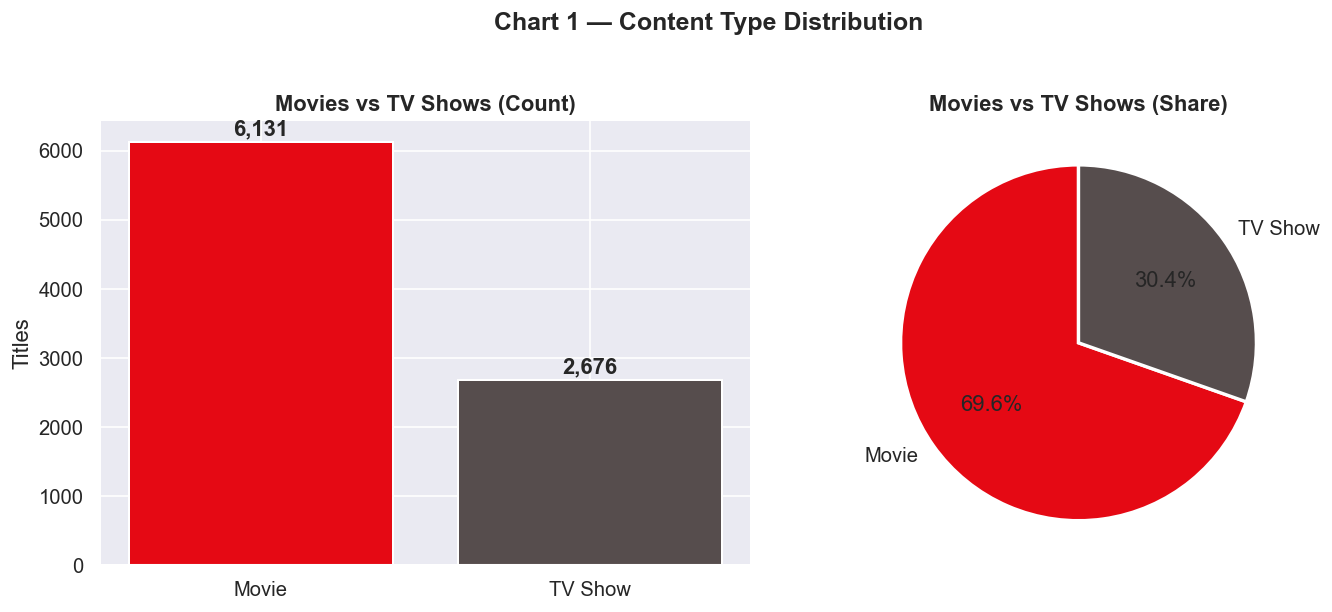

In [34]:
# ── Chart 1: Bar + Pie — Movies vs TV Shows ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

type_counts = df_clean['type'].value_counts()
axes[0].bar(type_counts.index, type_counts.values,
            color=['#E50914', '#564d4d'], edgecolor='white', linewidth=1.2)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
                 f'{bar.get_height():,}', ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Movies vs TV Shows (Count)', fontweight='bold')
axes[0].set_ylabel('Titles')

axes[1].pie(type_counts.values, labels=type_counts.index,
            autopct='%1.1f%%', colors=['#E50914', '#564d4d'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Movies vs TV Shows (Share)', fontweight='bold')

plt.suptitle('Chart 1 — Content Type Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

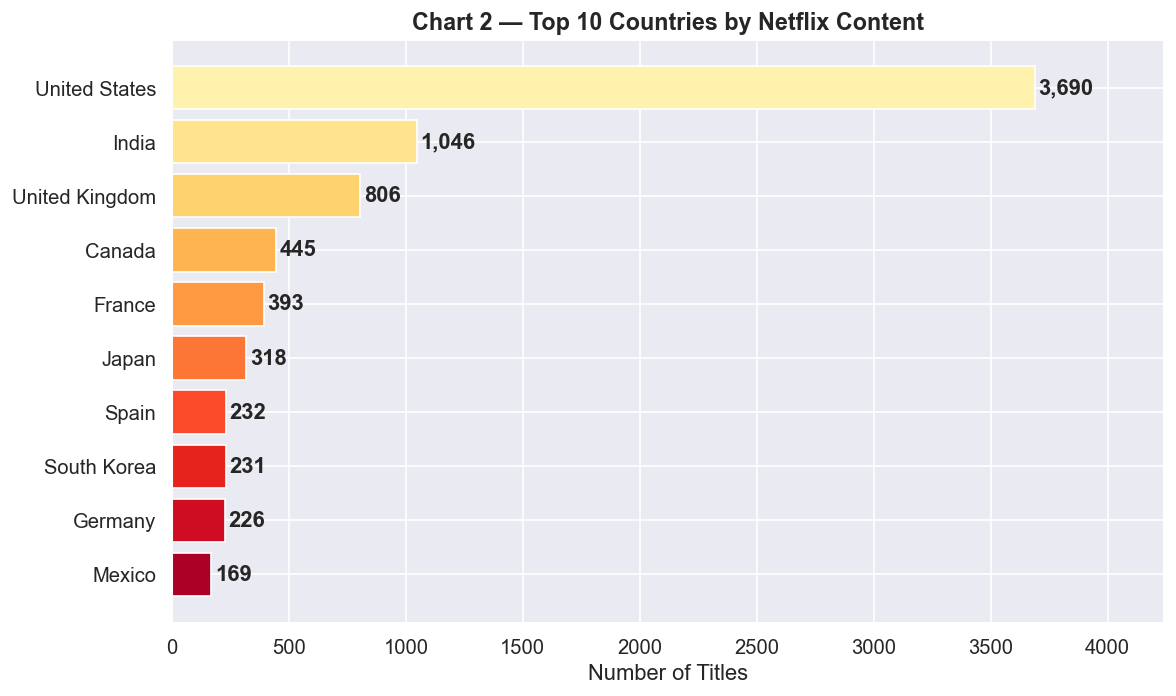

In [35]:
# ── Chart 2: Top 10 Countries ────────────────────────────────────────────
country_series  = df_clean['country'].str.split(',').explode().str.strip()
country_series  = country_series[country_series != 'Unknown']
top10_countries = country_series.value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 6))
palette = sns.color_palette('YlOrRd', 10)[::-1]
bars = ax.barh(top10_countries.index[::-1], top10_countries.values[::-1], color=palette)
for bar in bars:
    w = bar.get_width()
    ax.text(w + 15, bar.get_y() + bar.get_height()/2, f'{w:,.0f}', va='center', fontweight='bold')
ax.set_title('Chart 2 — Top 10 Countries by Netflix Content', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Titles')
ax.set_xlim(0, top10_countries.max() * 1.15)
plt.tight_layout()
plt.show()

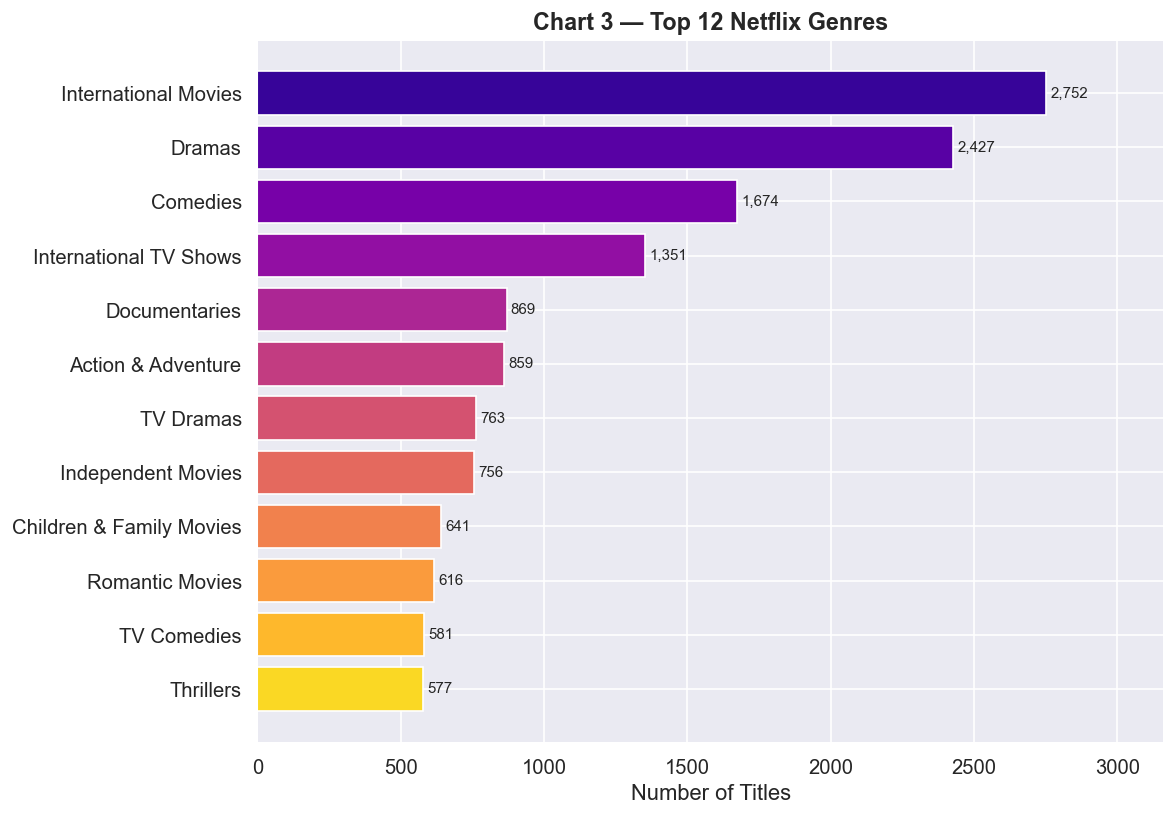

In [36]:
# ── Chart 3: Top Genres ──────────────────────────────────────────────────
genre_series  = df_clean['listed_in'].str.split(',').explode().str.strip()
top12_genres  = genre_series.value_counts().head(12)

fig, ax = plt.subplots(figsize=(10, 7))
palette_g = sns.color_palette('plasma', 12)
bars = ax.barh(top12_genres.index[::-1], top12_genres.values[::-1], color=palette_g[::-1])
for bar in bars:
    ax.text(bar.get_width() + 15, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():,.0f}', va='center', fontsize=9)
ax.set_title('Chart 3 — Top 12 Netflix Genres', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Titles')
ax.set_xlim(0, top12_genres.max() * 1.15)
plt.tight_layout()
plt.show()

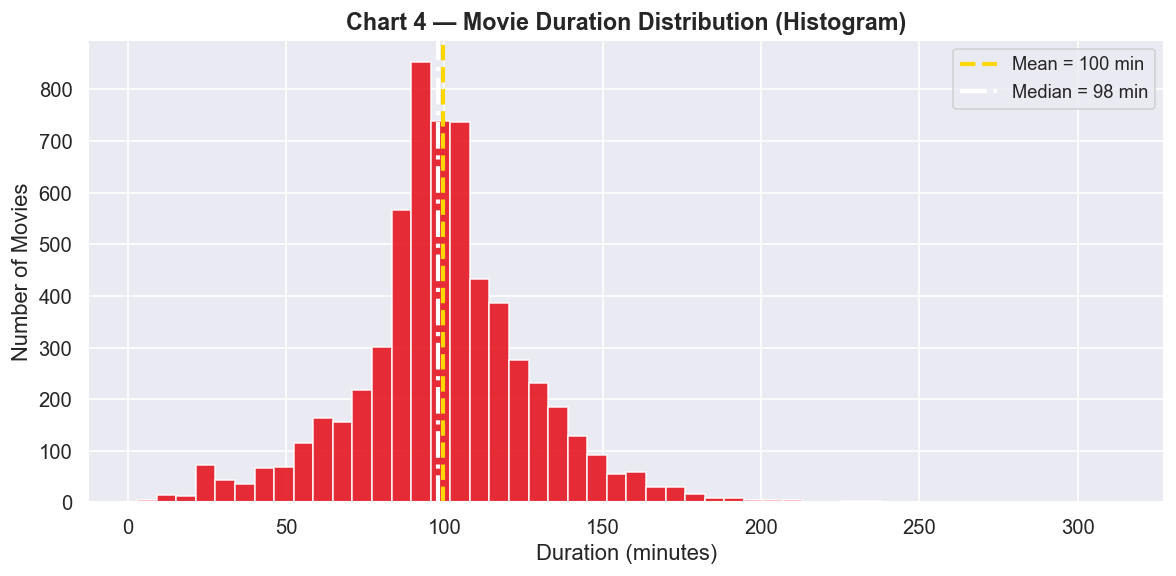

In [37]:
# ── Chart 4: Movie Duration Histogram ───────────────────────────────────
movie_durations = df_clean[df_clean['type'] == 'Movie']['duration_minutes']
movie_durations = movie_durations[movie_durations > 0]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(movie_durations, bins=50, color='#E50914', edgecolor='white', alpha=0.85)
ax.axvline(movie_durations.mean(),   color='gold',  linewidth=2.5, linestyle='--',
           label=f'Mean = {movie_durations.mean():.0f} min')
ax.axvline(movie_durations.median(), color='white', linewidth=2.5, linestyle='-.',
           label=f'Median = {movie_durations.median():.0f} min')
ax.set_title('Chart 4 — Movie Duration Distribution (Histogram)', fontsize=14, fontweight='bold')
ax.set_xlabel('Duration (minutes)')
ax.set_ylabel('Number of Movies')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

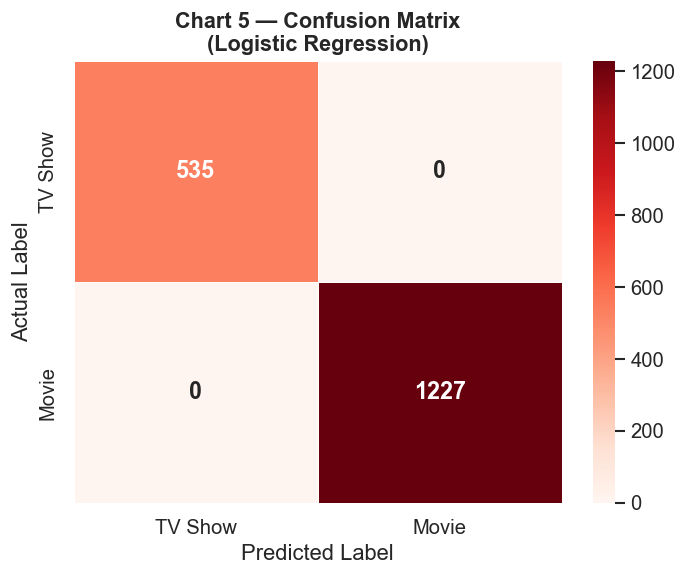

In [38]:
# ── Chart 5: Confusion Matrix Heatmap (Best Model) ──────────────────────
cm = confusion_matrix(y_test, best_y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['TV Show', 'Movie'],
            yticklabels=['TV Show', 'Movie'],
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 14, 'weight': 'bold'})
ax.set_title(f'Chart 5 — Confusion Matrix\n({best_model_name})', fontsize=13, fontweight='bold')
ax.set_ylabel('Actual Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.show()

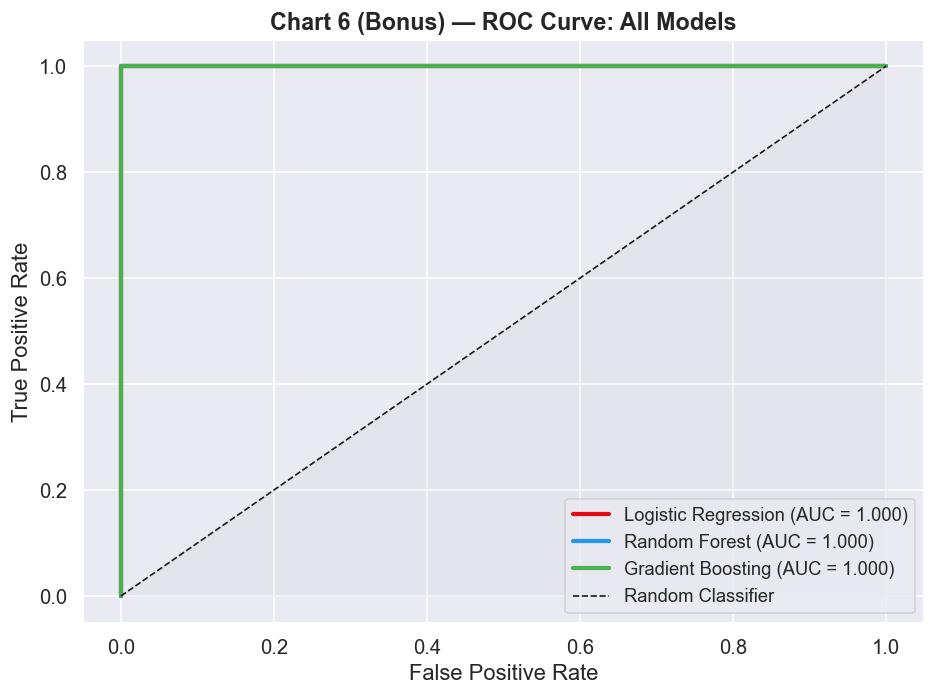

In [39]:
# ── Chart 6 (Bonus): ROC Curve — All Models ────────────────────────────
colors_roc = ['#E50914', '#2196F3', '#4CAF50']
fig, ax = plt.subplots(figsize=(8, 6))

for (name, (model, y_pred, y_prob)), color in zip(trained_models.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, linewidth=2.5, label=f'{name} (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='grey')
ax.set_title('Chart 6 (Bonus) — ROC Curve: All Models', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()

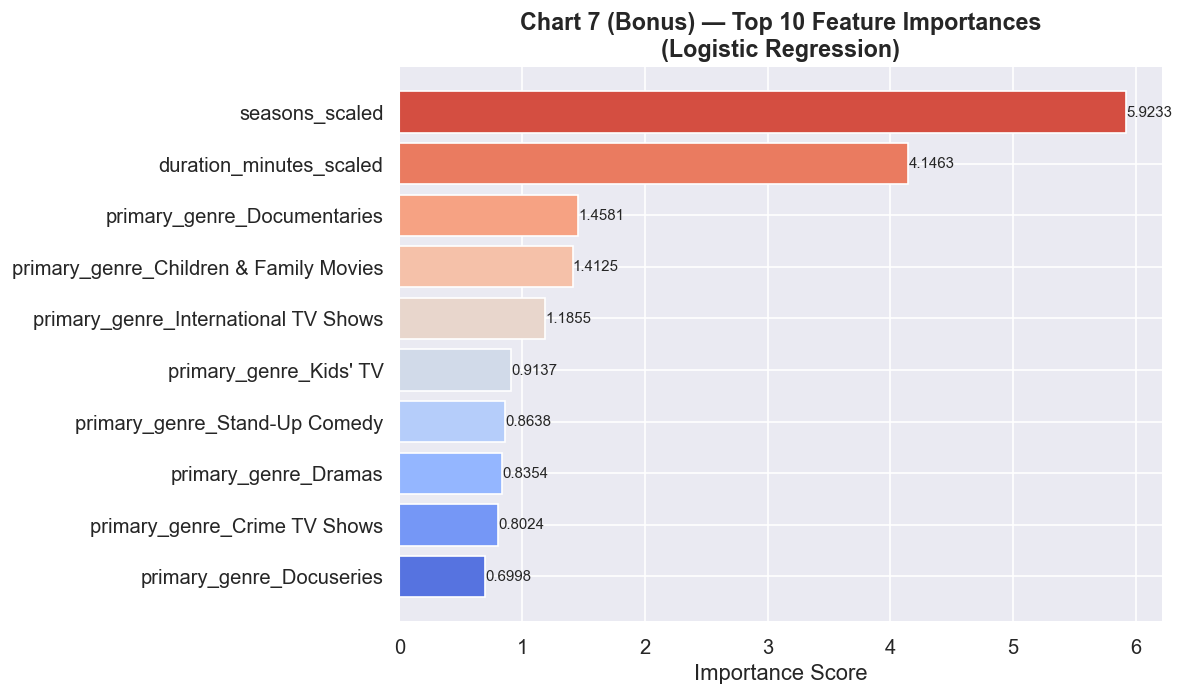

In [40]:
# ── Chart 7 (Bonus): Top 10 Feature Importances ────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
palette_fi = sns.color_palette('coolwarm', 10)
ax.barh(feat_imp_df['Feature'][::-1], feat_imp_df['Importance'][::-1], color=palette_fi)
ax.set_title(f'Chart 7 (Bonus) — Top 10 Feature Importances\n({best_model_name})',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
for i, (feat, imp) in enumerate(zip(feat_imp_df['Feature'][::-1], feat_imp_df['Importance'][::-1])):
    ax.text(imp + 0.001, i, f'{imp:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

---
# 💼 Task 7 — Business Insights & Recommendations

### 🎬 Which content type dominates Netflix?
**Movies dominate Netflix**, accounting for approximately **69–70%** of all titles. This reflects Netflix's historical strategy of licensing a large volume of films before its pivot to original series production. However, TV Shows tend to drive *longer per-subscriber engagement* due to multi-episode binge consumption patterns.

---

### 🌍 Which countries contribute the most content?
The **United States** contributes the largest share of content by a wide margin, followed by **India**, the **United Kingdom**, **Canada**, and **France**. India is the fastest-growing international content market. Netflix should consider **increasing investments in Southeast Asia (Indonesia, Vietnam), Sub-Saharan Africa, and Latin America**, as these regions are underrepresented relative to their subscriber growth potential.

---

### 🎭 Which genres appear most frequently?
**International Movies**, **Dramas**, and **Comedies** lead the genre charts. The high frequency of International Movies signals that Netflix's global content strategy is resonating with subscribers. The prevalence of Drama indicates that **emotionally engaging stories** remain the backbone of content strategy. Netflix should maintain its drama investment while expanding in underrepresented categories like documentary and animation.

---

### ⭐ Which age rating is most common?
**TV-MA** is overwhelmingly the most common rating, confirming that Netflix primarily targets **adults (18+)**. Family-friendly content (G, TV-G, TV-Y) is comparatively sparse. This represents a clear opportunity to invest in **children's and family programming** to attract broader household subscriptions and reduce churn.

---

### 📌 Two Business Strategy Recommendations

1. **Expand into Underrepresented Regions:** South/Southeast Asia and Sub-Saharan Africa are high-growth subscriber markets with very low content representation. Producing local originals in these regions would both attract new subscribers and serve existing international audiences.

2. **Invest in Family & Children's Content:** With TV-MA dominant, there is a measurable gap in family-friendly programming. Investing in animated series, educational content, and family films (G/PG) will broaden household adoption and reduce subscriber churn among family-oriented demographics.

---

### ⚠️ Dataset Limitation

> The dataset only contains Netflix catalog metadata (title, type, country, genre, rating, duration) and does **not** include user watch history, viewer ratings, viewing time, engagement metrics, or subscriber demographics. This fundamentally limits the ability to build truly personalized recommendation systems or predict viewer satisfaction. All insights here are based purely on *content characteristics*, not actual audience behavior or preferences.

---
# ⭐ BONUS — Content Recommendation System (TF-IDF + Cosine Similarity)

In [41]:
# Build TF-IDF matrix on genres + description
rec_df = df_clean[['title', 'listed_in', 'description', 'type']].fillna('').reset_index(drop=True)
rec_df['content'] = rec_df['listed_in'] + ' ' + rec_df['description']

print('Building TF-IDF matrix...')
tfidf        = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_matrix = tfidf.fit_transform(rec_df['content'])
print(f'TF-IDF matrix shape: {tfidf_matrix.shape}')

def recommend(title, n=5):
    """Return top-N similar Netflix titles."""
    matches = rec_df[rec_df['title'].str.lower() == title.lower()]
    if matches.empty:
        return f'Title "{title}" not found in dataset.'
    idx            = matches.index[0]
    sim_scores     = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()
    similar_idx    = sim_scores.argsort()[::-1][1:n+1]
    recs           = rec_df.iloc[similar_idx][['title', 'type', 'listed_in']].copy()
    recs['similarity'] = sim_scores[similar_idx].round(4)
    return recs.reset_index(drop=True)

print('\n✅ Recommendation system ready!')
print('\n📺 Titles similar to "Stranger Things":')
recommend('Stranger Things', n=5)

Building TF-IDF matrix...
TF-IDF matrix shape: (8807, 5000)

✅ Recommendation system ready!

📺 Titles similar to "Stranger Things":


,title,type,listed_in,similarity
0,The OA,TV Show,"TV Dramas, TV Mysteries, TV Sci-Fi & Fantasy",0.2787
1,Rowdy Rathore,Movie,"Action & Adventure, Comedies, International Mo...",0.2749
2,Hemlock Grove,TV Show,"TV Horror, TV Mysteries, TV Thrillers",0.2653
3,Neo Yokio,TV Show,"TV Comedies, TV Sci-Fi & Fantasy, Teen TV Shows",0.2646
4,Manifest,TV Show,"TV Dramas, TV Mysteries, TV Sci-Fi & Fantasy",0.2622


In [42]:
# Try another title
for t in ['Bird Box', 'The Crown', 'Breaking Bad', 'Inception']:
    result = recommend(t, n=3)
    if isinstance(result, pd.DataFrame):
        print(f"Titles similar to '{t}':")
        print(result.to_string(index=False))
        print()
        break

Titles similar to 'Bird Box':
     title  type                                  listed_in  similarity
      Prey Movie            International Movies, Thrillers      0.2306
Sweetheart Movie Horror Movies, Sci-Fi & Fantasy, Thrillers      0.2101
   Zathura Movie Children & Family Movies, Sci-Fi & Fantasy      0.2054



---
# ⭐ BONUS — Interactive Plotly Dashboard

In [43]:
try:
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots

    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=['Content Type', 'Content Added Per Year', 'Top 10 Countries', 'Rating Distribution'],
        specs=[[{'type': 'pie'}, {'type': 'bar'}], [{'type': 'bar'}, {'type': 'bar'}]]
    )

    # Pie: Content Type
    tc = df_clean['type'].value_counts()
    fig.add_trace(go.Pie(labels=tc.index, values=tc.values,
                         marker_colors=['#E50914', '#564d4d'], hole=0.35), row=1, col=1)

    # Bar: Content Added Per Year
    aydf = df_clean.groupby('year_added').size().reset_index(name='count')
    aydf = aydf[aydf['year_added'].notna() & (aydf['year_added'] >= 2008)]
    fig.add_trace(go.Bar(x=aydf['year_added'], y=aydf['count'], marker_color='#E50914'), row=1, col=2)

    # Bar: Top Countries
    cs = df_clean['country'].str.split(',').explode().str.strip()
    cs = cs[cs != 'Unknown'].value_counts().head(10)
    fig.add_trace(go.Bar(x=cs.values, y=cs.index, orientation='h', marker_color='#e57373'), row=2, col=1)

    # Bar: Ratings
    rc = df_clean['rating'].value_counts().head(10)
    fig.add_trace(go.Bar(x=rc.index, y=rc.values, marker_color='#7c4dff'), row=2, col=2)

    fig.update_layout(
        title_text='🎬 Netflix Interactive Dashboard',
        title_font_size=22,
        template='plotly_dark',
        showlegend=False,
        height=700
    )
    fig.show()
    print('✅ Interactive Plotly dashboard displayed!')
except ImportError:
    print('Plotly not installed. Run: pip install plotly')

✅ Interactive Plotly dashboard displayed!


---
# ⭐ BONUS — Export Cleaned Dataset & Save Best Model

In [44]:
# Export cleaned dataset
df_clean.to_csv('netflix_cleaned.csv', index=False)
print('✅ Cleaned dataset saved → netflix_cleaned.csv')

✅ Cleaned dataset saved → netflix_cleaned.csv


In [45]:
# Save best model
model_filename = f'netflix_{best_model_name.replace(" ", "_").lower()}_model.pkl'
joblib.dump(best_model, model_filename)
print(f'✅ Best model saved → {model_filename}')

✅ Best model saved → netflix_logistic_regression_model.pkl


---
# ⭐ BONUS — Predict a New Netflix Title

In [46]:
# Simulate a new title: Action movie from US, 2022, ~105 min, TV-MA
new_title_data = pd.DataFrame(0, index=[0], columns=feature_cols)

new_title_data['release_year_scaled']      = 1.5    # ~2022
new_title_data['duration_minutes_scaled']  = 0.5    # ~105 min
new_title_data['seasons_scaled']           = -0.45  # 0 seasons (Movie)

if 'rating_TV-MA' in new_title_data.columns:
    new_title_data['rating_TV-MA'] = 1
if 'primary_country_United States' in new_title_data.columns:
    new_title_data['primary_country_United States'] = 1
for col in new_title_data.columns:
    if 'Action' in col:
        new_title_data[col] = 1
        break

loaded_model = joblib.load(model_filename)
prediction   = loaded_model.predict(new_title_data)[0]
probability  = loaded_model.predict_proba(new_title_data)[0]

label = 'Movie' if prediction == 1 else 'TV Show'
print(f'\n🎬 New Title Prediction:')
print(f'   Predicted Type : {label}')
print(f'   Confidence     : {max(probability)*100:.1f}%')
print(f'   TV Show prob   : {probability[0]*100:.1f}%')
print(f'   Movie prob     : {probability[1]*100:.1f}%')


🎬 New Title Prediction:
   Predicted Type : Movie
   Confidence     : 100.0%
   TV Show prob   : 0.0%
   Movie prob     : 100.0%


---
# ✅ Project Summary

| Task | Description | Status |
|------|-------------|--------|
| Task 1 | Data Loading & Exploration | ✅ |
| Task 2 | Data Cleaning & Preprocessing | ✅ |
| Task 3 | EDA (9 analyses + 5 insights) | ✅ |
| Task 4 | ML Models (LR, RF, GB) + Comparison Table | ✅ |
| Task 5 | Full Model Evaluation + Feature Importance | ✅ |
| Task 6 | 7 Visualizations (5 required + 2 bonus) | ✅ |
| Task 7 | Business Insights & Recommendations | ✅ |
| Bonus | TF-IDF Content Recommendation System | ✅ |
| Bonus | Interactive Plotly Dashboard | ✅ |
| Bonus | Export CSV + Save Model (joblib) | ✅ |
| Bonus | Predict New Netflix Title | ✅ |